In [ ]:
from google.colab import files
upload = files.upload()

Saving Used Car Dataset.csv to Used Car Dataset (1).csv


     Unnamed: 0                                           car_name  \
0             0                    2017 Mercedes-Benz S-Class S400   
1             1  2020 Nissan Magnite Turbo CVT XV Premium Opt BSVI   
2             2                       2018 BMW X1 sDrive 20d xLine   
3             3                           2019 Kia Seltos GTX Plus   
4             4                    2019 Skoda Superb LK 1.8 TSI AT   
..          ...                                                ...   
196         196                        2018 BMW X1 sDrive20i xLine   
197         197           2020 Toyota Innova Crysta 2.8 ZX AT BSIV   
198         198                 2019 Mercedes-Benz S-Class S 350 d   
199         199                 2014 Hyundai Grand i10 Asta Option   
200         200                 2019 BMW 5 Series 520d Luxury Line   

    registration_year fuel_type  seats  kms_driven    ownsership transmission  \
0              17-Jul    Petrol      5       56000   First Owner    Automatic 

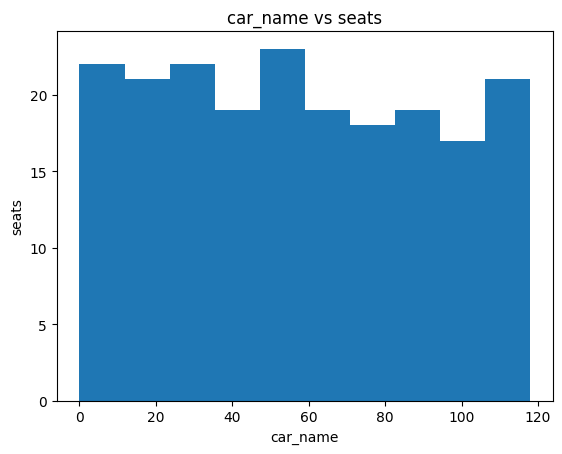

Scatter:


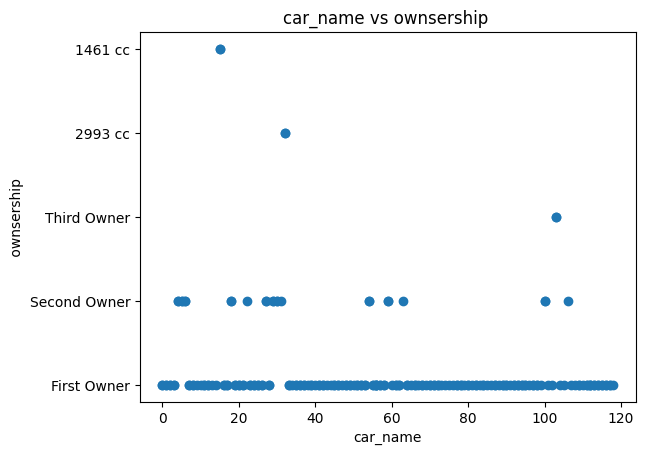

plot:


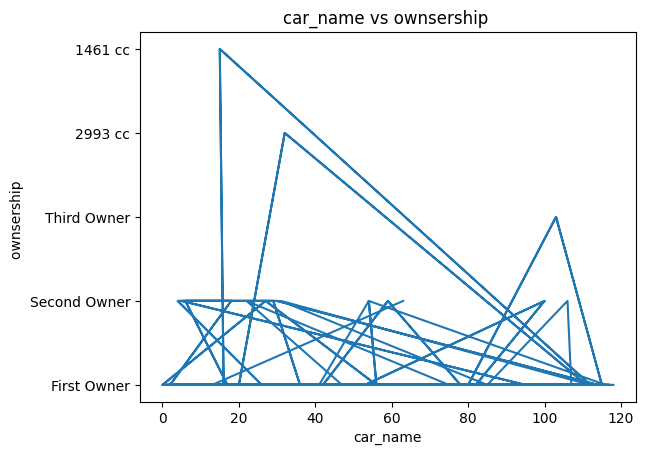

Barchart:


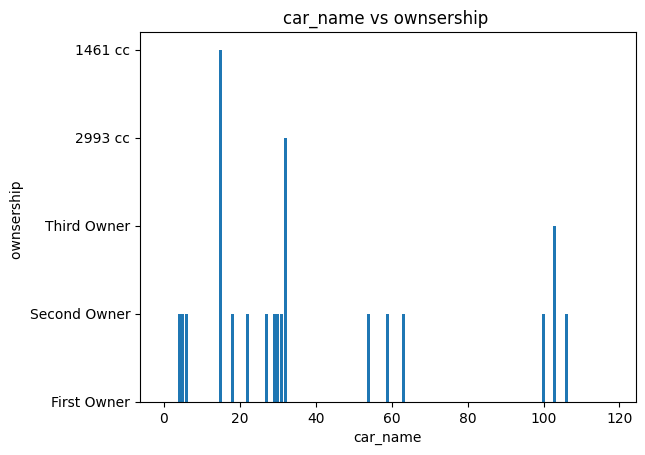

Boxplot:


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

<Figure size 640x480 with 1 Axes>

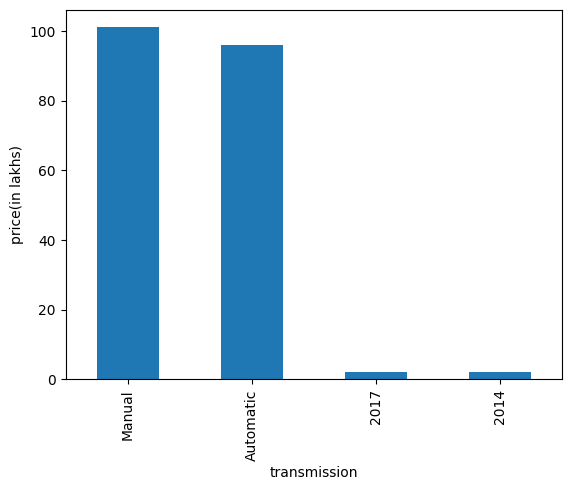

NameError: name 'correlationi_columns' is not defined

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv('Used Car Dataset.csv')
df = pd.DataFrame(df)
print(df)

print("Head value:",df.head())
print("Tail value:",df.tail())
print("Shape of data:",df.shape)
print("Data type of data:",df.dtypes)
print("Columns Data:",df.columns)
print("Information about data:",df.info)
print("Description about data:",df.describe)
print("Specfic row data:",df[["car_name","seats" ,"registration_year"]])
print("Specfic values:",df[df["transmission"]=="Manual"])

#Data processing

print("duplicate:",df.duplicated())
print("Counts of ownership:",df["ownsership"].value_counts())

from sklearn.preprocessing import LabelEncoder,MinMaxScaler,StandardScaler
l = LabelEncoder()
df["car_name"] = l.fit_transform(df["car_name"])
print(df)
scaler = MinMaxScaler()
df["price(in lakhs)"] = scaler.fit_transform(df[["price(in lakhs)"]])
print(df)

#Statistics

print("mean of price(in lakhs):",df['price(in lakhs)'].mean())
print("median of price(in lakhs):",df['price(in lakhs)'].median())
print("mode of price(in lakhs):",df['price(in lakhs)'].mode())
print("Standard deviations of price(in lakhs):",df['price(in lakhs)'].std())
print("variance of price(in lakhs):",df['price(in lakhs)'].var())
print("minimum of price(in lakhs):",df['price(in lakhs)'].min())
print("maximum of price(in lakhs):",df['price(in lakhs)'].max())
print("Range of price(in lakhs):",df['price(in lakhs)'].max()-df['price(in lakhs)'].min())

numeric_df = df.select_dtypes(include=np.number)

print("Mean", numeric_df.mean())
print("Median", numeric_df.median())
print("Mode", numeric_df.mode())
print("variance", numeric_df.var())
print("Standard deviation", numeric_df.std())

Q1 = df["price(in lakhs)"].quantile(0.25)
Q3 = df["price(in lakhs)"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)
outliers = df[
    (df["price(in lakhs)"] < lower) |
    (df["price(in lakhs)"] > upper)
]
print("Outliers:",outliers)

print("corrosion:",
    df[
        ["price(in lakhs)","seats","kms_driven"]
      ].corr()
)

import matplotlib.pyplot as plt
print("histogram:")
plt.hist(
    df['car_name']
)
plt.xlabel('car_name')
plt.ylabel('seats')
plt.title('car_name vs seats')
plt.show()

print("Scatter:")
plt.scatter(
    df['car_name'],
    df['ownsership']
)
plt.xlabel('car_name')
plt.ylabel(' ownsership ')
plt.title('car_name vs ownsership ')
plt.show()

print("plot:")
plt.plot(
    df['car_name'],
    df['ownsership']
)
plt.xlabel('car_name')
plt.ylabel('ownsership ')
plt.title('car_name vs ownsership ')
plt.show()


print("Barchart:")
plt.bar(
    df['car_name'],
    df['ownsership']
)
plt.xlabel('car_name')
plt.ylabel('ownsership ')
plt.title('car_name vs ownsership ')
plt.show()

print("Boxplot:")
plt.box(
    df['car_name'],
    df['ownsership']
)
plt.xlabel('car_name')
plt.ylabel('ownsership ')
plt.title('car_name vs ownsership ')
plt.show()

count= df['transmission'].value_counts()
count.plot(kind='bar')
plt.xlabel('transmission')
plt.ylabel('price(in lakhs)')
plt.show()

Correlation_columns =["price(in lakhs)","seats","kms_driven" ]
Correlation_matrix =df[correlationi_columns].corr()
print(Correlation_matrix)

import seaborn as sns
sns.heatmap(
    Correlation_matrix,annot=True,camp="coolwarm",fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

df["registration_year"] = pd.to_datetime(
    df["registration_year"],
    errors="coerce"
).dt.year

df["seats"] = pd.to_numeric(
    df["seats"],
    errors="coerce"
)

df["kms_driven"] = pd.to_numeric(
    df["kms_driven"],
    errors="coerce"
)

df["mileage(kmpl)"] = pd.to_numeric(
    df["mileage(kmpl)"],
    errors="coerce"
)

df["price(in lakhs)"] = pd.to_numeric(
    df["price(in lakhs)"],
    errors="coerce"
)

df = df.dropna(
    subset=[
        "registration_year",
        "kms_driven",
        "mileage(kmpl)",
        "seats",
        "price(in lakhs)"
    ]
)

X = df[[
    "registration_year",
    "kms_driven",
    "mileage(kmpl)",
    "seats"
]]
y = df["price(in lakhs)"]



x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


model = DecisionTreeRegressor(random_state=42,max_depth=5)

model.fit(x_train, y_train)


y_pred = model.predict(x_test)

print("Predicted values:")
print(y_pred)


r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

result = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print("\nActual vs Predicted:")
print(result.head(10))
print ("Tree:")

plt.figure(figsize=(15, 8))

plot_tree(
    model,
    feature_names=X.columns,
    filled=True,
    fontsize=9
)

plt.show()

from sklearn.linear_model import LinearRegression

print("Linear Regression:" )
X = df [

["registration_year",
    "kms_driven",
    "mileage(kmpl)",
    "seats"

]
]

y = df ["price(in lakhs)"]

model = LinearRegression()

model.fit(X, y)

print("Model training completed successfully.")

print("Intercept:", model.intercept_)

print("\nCoefficients:")

for feature, coefficient in zip(X.columns, model.coef_):

   print(feature,":",coefficient)

predictions = model.predict(X)

print("Predicted Sales:")

print(predictions)

comparison = pd.DataFrame({
  "Actual Sales": y,

  "Predicted Sales": predictions

})

print(comparison)

new_car = pd.DataFrame({
    "registration_year": [2020],
    "kms_driven": [35000],
    "mileage(kmpl)": [18],
    "seats": [5]
})

new_prediction = model.predict(new_car)

print("\nNew Car:")
print(new_car)

print("\nPredicted Price:")
print(new_prediction[0], "lakhs")